# 07 - Risk Analizi ve Açıklanabilir Yapay Zeka (SHAP)

Bu notebook'ta:
1. Tahmin edilen değerler üzerinden **Normal / Yoğun / Kritik** risk sınıflandırması yapılmaktadır.
2. **Feature Importance** ve **SHAP** analizi ile model kararları yorumlanabilir hale getirilmektedir.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
import shap
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, r2_score, classification_report
print('SHAP version:', shap.__version__)

SHAP version: 0.52.0


## Veri + Feature Engineering

In [5]:
df = pd.read_csv('../data/raw/request_level_data.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

for lag in [1, 2, 3]:
    df[f'response_time_lag_{lag}'] = df['response_time_ms'].shift(lag)

df['response_time_roll_mean_5']  = df['response_time_ms'].shift(1).rolling(5).mean()
df['response_time_roll_mean_10'] = df['response_time_ms'].shift(1).rolling(10).mean()
df['response_time_roll_std_5']   = df['response_time_ms'].shift(1).rolling(5).std()

le = joblib.load('../models/label_encoder.pkl')
df['endpoint_encoded'] = le.transform(df['endpoint_name'])

df = df.dropna().reset_index(drop=True)
print(f'Veri boyutu: {df.shape}')

Veri boyutu: (29199, 21)


In [6]:
features = [
    'payload_size', 'active_requests', 'rps_10s', 'requests_last_60s',
    'response_time_lag_1', 'response_time_lag_2', 'response_time_lag_3',
    'response_time_roll_mean_5', 'response_time_roll_mean_10',
    'response_time_roll_std_5', 'endpoint_encoded'
]
target = 'response_time_ms'
WINDOW_SIZE = 10

def create_window(df, features, target, window_size):
    X, y = [], []
    for i in range(len(df) - window_size):
        X.append(df[features].iloc[i:i+window_size].values)
        y.append(df[target].iloc[i+window_size])
    return np.array(X), np.array(y)

X, y = create_window(df, features, target, WINDOW_SIZE)
X_flat = X.reshape(X.shape[0], -1)

split = int(len(X_flat) * 0.8)
X_train, X_test = X_flat[:split], X_flat[split:]
y_train, y_test = y[:split], y[split:]
print(f'Test: {X_test.shape}')

Test: (5838, 110)


## Enhanced RF Yükleme

In [7]:
rf = joblib.load('../models/random_forest_enhanced.pkl')
y_pred_rf = rf.predict(X_test)
print(f'MAE: {mean_absolute_error(y_test, y_pred_rf):.2f}')
print(f'R2:  {r2_score(y_test, y_pred_rf):.4f}')

MAE: 88.17
R2:  0.4096


## Eşik Analizi - Response Time Persentilleri

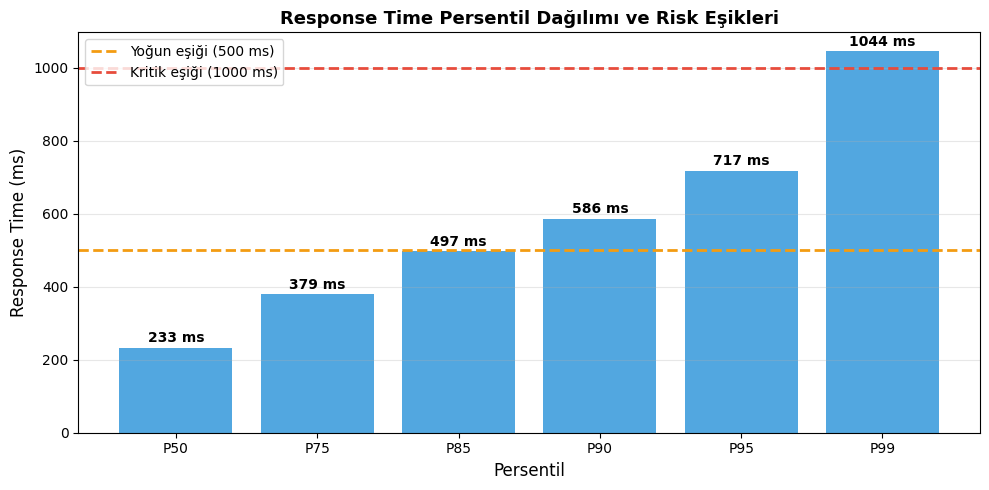

Persentil Analizi:
  P50: 233 ms
  P75: 379 ms
  P85: 497 ms
  P90: 586 ms
  P95: 717 ms
  P99: 1044 ms

Seçilen eşikler:
  Normal → Yoğun: 500 ms (P85 civarı)
  Yoğun → Kritik: 1000 ms (P99 civarı)


In [13]:
percentiles = [50, 75, 85, 90, 95, 99]
values = [df['response_time_ms'].quantile(p/100) for p in percentiles]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar([f'P{p}' for p in percentiles], values, color='#3498db', alpha=0.85)

# Eşik çizgileri
ax.axhline(500,  color='#f39c12', linestyle='--', linewidth=2, label='Yoğun eşiği (500 ms)')
ax.axhline(1000, color='#e74c3c', linestyle='--', linewidth=2, label='Kritik eşiği (1000 ms)')

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
            f'{val:.0f} ms', ha='center', fontsize=10, fontweight='bold')

ax.set_xlabel('Persentil', fontsize=12)
ax.set_ylabel('Response Time (ms)', fontsize=12)
ax.set_title('Response Time Persentil Dağılımı ve Risk Eşikleri', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig('../outputs/threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Sayısal özet
print('Persentil Analizi:')
for p, v in zip(percentiles, values):
    print(f'  P{p}: {v:.0f} ms')
print(f'\nSeçilen eşikler:')
print(f'  Normal → Yoğun: 500 ms (P85 civarı)')
print(f'  Yoğun → Kritik: 1000 ms (P99 civarı)')

Risk eşikleri veri dağılımı temel alınarak belirlenmiştir. 500 ms eşiği verideki 85. persentile karşılık gelmekte olup, bu değerin üzerindeki istekler sistemin olağan performansından sapma gösterdiğini ifade etmektedir. 1000 ms eşiği ise 99. persentile yakın olup, yalnızca en uç gecikme değerlerini Kritik olarak sınıflandırmaktadır.

## Risk Sınıflandırması

| Sınıf | Eşik |
|-------|------|
| Normal | < 500 ms |
| Yoğun | 500–1000 ms |
| Kritik | > 1000 ms |

In [8]:
def classify_risk(ms):
    if ms < 500: return 'Normal'
    elif ms < 1000: return 'Yoğun'
    return 'Kritik'

risk_df = pd.DataFrame({'y_true': y_test, 'y_pred_rf': y_pred_rf})
risk_df['risk_true'] = risk_df['y_true'].apply(classify_risk)
risk_df['risk_pred'] = risk_df['y_pred_rf'].apply(classify_risk)

print('Gerçek:\n', risk_df['risk_true'].value_counts())
print('\nTahmin:\n', risk_df['risk_pred'].value_counts())

Gerçek:
 risk_true
Normal    5066
Yoğun      730
Kritik      42
Name: count, dtype: int64

Tahmin:
 risk_pred
Normal    5480
Yoğun      356
Kritik       2
Name: count, dtype: int64


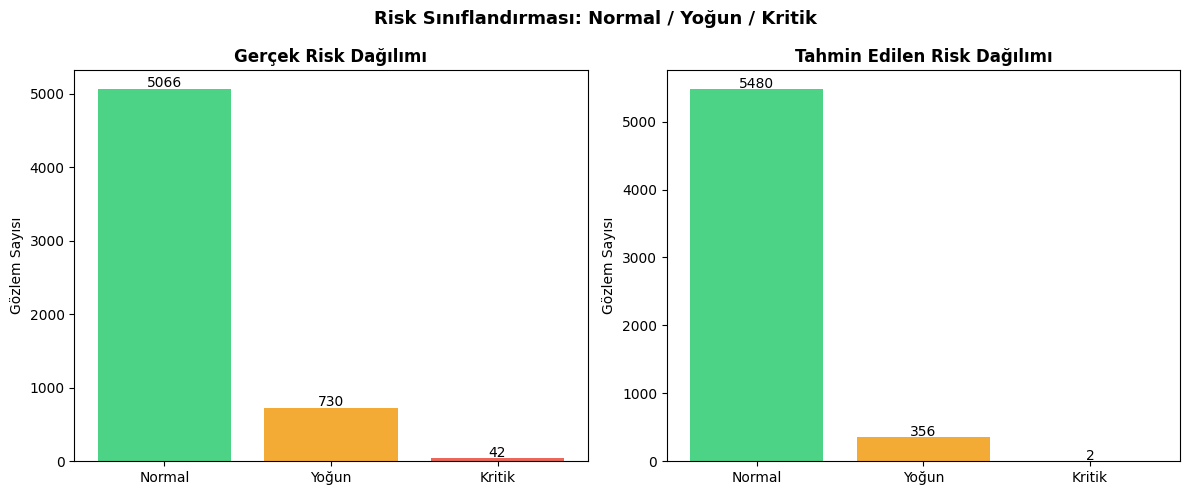

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
risk_colors = {'Normal': '#2ecc71', 'Yoğun': '#f39c12', 'Kritik': '#e74c3c'}
risk_order  = ['Normal', 'Yoğun', 'Kritik']

for ax, col, title in zip(axes, ['risk_true', 'risk_pred'],
                          ['Gerçek Risk Dağılımı', 'Tahmin Edilen Risk Dağılımı']):
    counts = risk_df[col].value_counts().reindex(risk_order, fill_value=0)
    bars = ax.bar(counts.index, counts.values,
                  color=[risk_colors[r] for r in counts.index], alpha=0.85)
    ax.set_title(title, fontweight='bold')
    ax.set_ylabel('Gözlem Sayısı')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(val), ha='center', fontsize=10)

plt.suptitle('Risk Sınıflandırması: Normal / Yoğun / Kritik', fontsize=13, fontweight='bold')
plt.tight_layout()
os.makedirs('../outputs', exist_ok=True)
plt.savefig('../outputs/risk_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
print(classification_report(risk_df['risk_true'], risk_df['risk_pred']))

              precision    recall  f1-score   support

      Kritik       0.50      0.02      0.05        42
      Normal       0.90      0.98      0.94      5066
       Yoğun       0.62      0.30      0.41       730

    accuracy                           0.89      5838
   macro avg       0.67      0.43      0.46      5838
weighted avg       0.86      0.89      0.87      5838



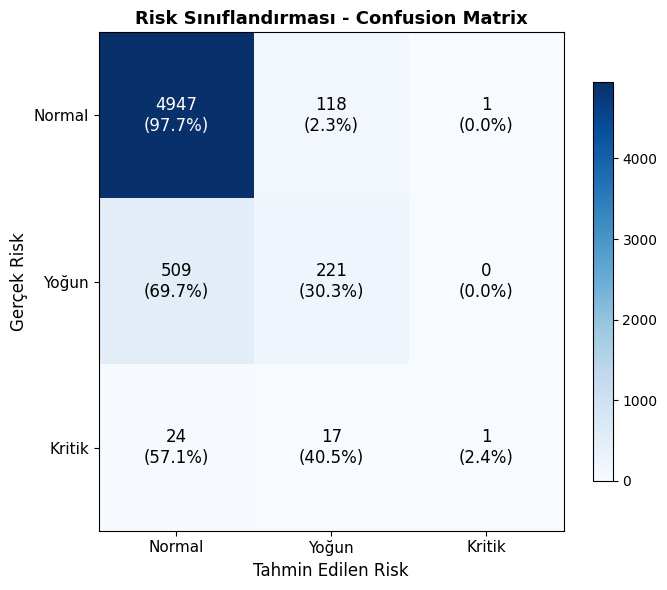

Sınıf bazlı doğruluk:
  Normal: 4947/5066 (97.7%)
  Yoğun: 221/730 (30.3%)
  Kritik: 1/42 (2.4%)

Genel doğruluk: 5169/5838 (88.5%)


In [11]:
# Confusion Matrix görselleştirme
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

risk_order = ['Normal', 'Yoğun', 'Kritik']
cm = confusion_matrix(risk_df['risk_true'], risk_df['risk_pred'], labels=risk_order)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cm, cmap='Blues', aspect='auto')

# Hücre değerlerini yaz
for i in range(len(risk_order)):
    for j in range(len(risk_order)):
        total = cm[i].sum()
        pct = cm[i, j] / total * 100 if total > 0 else 0
        ax.text(j, i, f'{cm[i,j]}\n({pct:.1f}%)',
                ha='center', va='center', fontsize=12,
                color='white' if cm[i,j] > cm.max()/2 else 'black')

ax.set_xticks(range(len(risk_order)))
ax.set_yticks(range(len(risk_order)))
ax.set_xticklabels(risk_order, fontsize=11)
ax.set_yticklabels(risk_order, fontsize=11)
ax.set_xlabel('Tahmin Edilen Risk', fontsize=12)
ax.set_ylabel('Gerçek Risk', fontsize=12)
ax.set_title('Risk Sınıflandırması - Confusion Matrix', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig('../outputs/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# Sınıf bazlı doğruluk oranları
print('Sınıf bazlı doğruluk:')
for i, risk in enumerate(risk_order):
    acc = cm[i, i] / cm[i].sum() * 100 if cm[i].sum() > 0 else 0
    print(f'  {risk}: {cm[i,i]}/{cm[i].sum()} ({acc:.1f}%)')
print(f'\nGenel doğruluk: {np.trace(cm)}/{cm.sum()} ({np.trace(cm)/cm.sum()*100:.1f}%)')

## Confusion Matrix Yorumu

Confusion matrix sonuçları, modelin risk sınıflandırma performansını üç açıdan ortaya koymaktadır:

**Genel doğruluk: %88.5** — modelin test setindeki tahminlerinin büyük çoğunluğu doğrudur.

**Normal sınıfı: %97.7 doğruluk** — sistemin stabil çalıştığı durumlar neredeyse eksiksiz tespit edilmektedir. Bu, operasyonel açıdan önemlidir; çünkü gereksiz alarm üretimi (false positive) minimize edilmiştir.

**Yoğun ve Kritik sınıflarındaki düşük recall:** Model, Yoğun durumların %30.3'ünü, Kritik durumların ise %2.4'ünü doğru sınıflandırabilmiştir. Bu durumun iki temel nedeni bulunmaktadır:

1. **Sınıf dengesizliği:** Risk eşikleri veri dağılımının P85 (500 ms) ve P99 (1000 ms) persentillerine göre belirlenmiştir. Bu nedenle test setinde 5066 Normal, 730 Yoğun ve yalnızca 42 Kritik gözlem bulunmaktadır. Kritik sınıfındaki düşük gözlem sayısı, modelin bu sınıfı öğrenmesini zorlaştırmaktadır.

2. **Regresyon tabanlı sınıflandırma:** Model doğrudan risk sınıfı tahmin etmemekte, önce response_time_ms değerini tahmin edip ardından eşik değerlere göre sınıflandırma yapılmaktadır. Tahmin değerindeki küçük sapmalar, özellikle eşik bölgelerindeki gözlemlerin yanlış sınıfa atanmasına yol açabilmektedir.

**İyileştirme önerileri - Gelecek Çalışmalar:** Sınıf ağırlıklandırması (class weighting), eşik optimizasyonu veya doğrudan sınıflandırma modeli kullanılarak Yoğun ve Kritik sınıflarının recall değerleri artırılabilir.

## SHAP Analizi

In [10]:
feature_names_flat = []
for t in range(WINDOW_SIZE):
    for f in features:
        feature_names_flat.append(f'{f}_t-{WINDOW_SIZE - t}')

np.random.seed(42)
explain_idx = np.random.choice(len(X_test), size=500, replace=False)
X_explain   = X_test[explain_idx]

print('SHAP hesaplanıyor... (1-2 dk)')
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_explain)
print(f'Tamamlandı. Shape: {shap_values.shape}')

SHAP hesaplanıyor... (1-2 dk)
Tamamlandı. Shape: (500, 110)


In [11]:
shap_grouped = np.zeros((shap_values.shape[0], len(features)))
for fi, feat in enumerate(features):
    indices = [j for j, name in enumerate(feature_names_flat) if name.startswith(feat + '_t-')]
    shap_grouped[:, fi] = shap_values[:, indices].sum(axis=1)

X_explain_df = pd.DataFrame(X_explain, columns=feature_names_flat)
X_explain_grouped = pd.DataFrame({
    feat: X_explain_df[[c for c in feature_names_flat if c.startswith(feat + '_t-')]].mean(axis=1)
    for feat in features
})
print('Grouped SHAP shape:', shap_grouped.shape)

Grouped SHAP shape: (500, 11)


C:\Users\bahar\AppData\Local\Temp\ipykernel_568\3298503202.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_grouped, X_explain_grouped, feature_names=features, show=False)


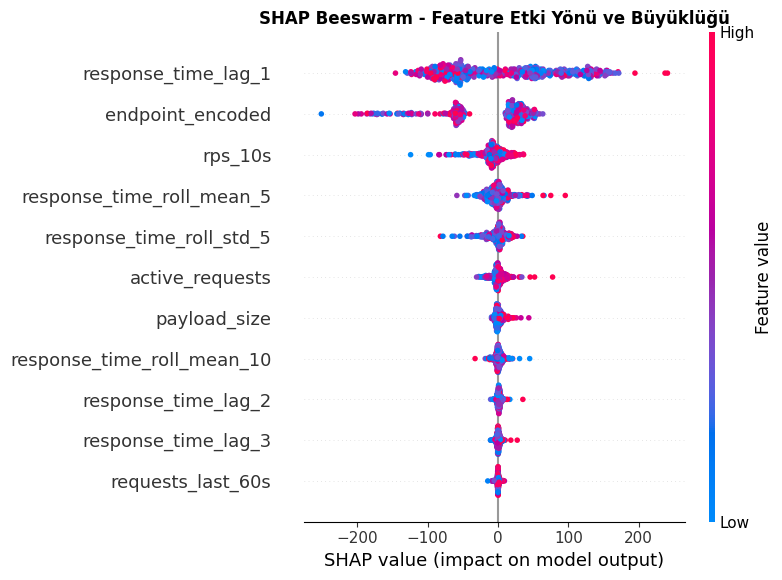

In [12]:
plt.figure(figsize=(9, 6))
shap.summary_plot(shap_grouped, X_explain_grouped, feature_names=features, show=False)
plt.title('SHAP Beeswarm - Feature Etki Yönü ve Büyüklüğü', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

C:\Users\bahar\AppData\Local\Temp\ipykernel_568\4197625871.py:2: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_grouped, X_explain_grouped, feature_names=features,


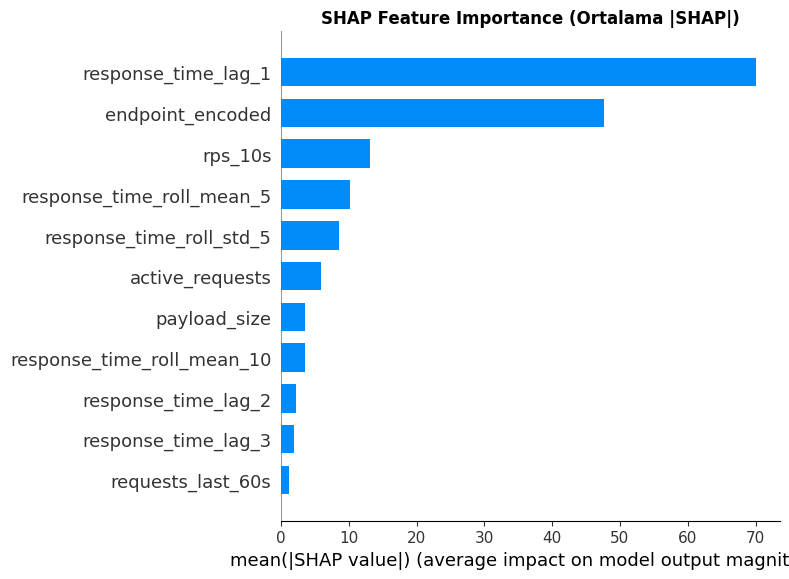

In [13]:
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_grouped, X_explain_grouped, feature_names=features,
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Ortalama |SHAP|)', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

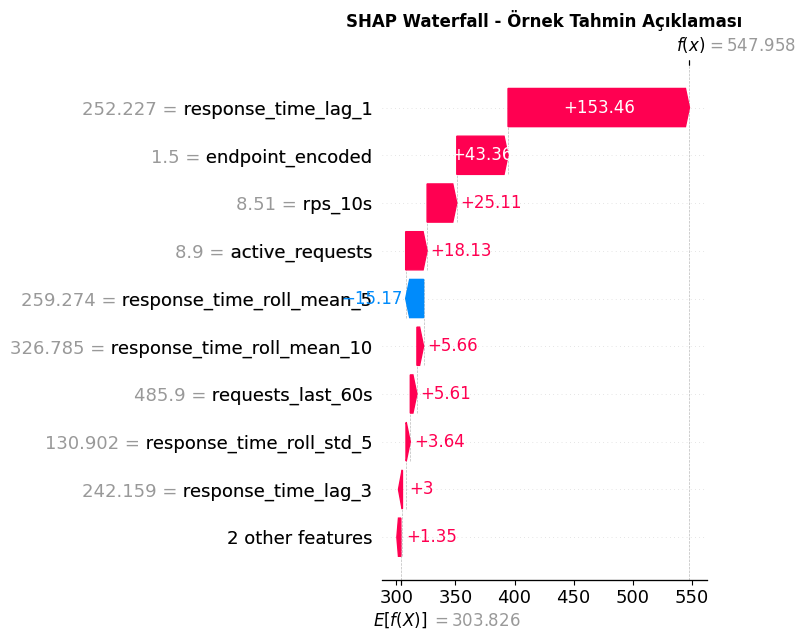

Gerçek: 651.8 ms  |  Tahmin: 548.0 ms


In [14]:
expected_value = explainer.expected_value
if isinstance(expected_value, np.ndarray):
    expected_value = float(expected_value[0])

shap.waterfall_plot(
    shap.Explanation(
        values=shap_grouped[0],
        base_values=expected_value,
        data=X_explain_grouped.iloc[0].values,
        feature_names=features
    ), show=False
)
plt.title('SHAP Waterfall - Örnek Tahmin Açıklaması', fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/shap_waterfall.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Gerçek: {y_test[explain_idx[0]]:.1f} ms  |  Tahmin: {y_pred_rf[explain_idx[0]]:.1f} ms')

## Endpoint Bazlı Model Performans Karşılaştırması

Endpoint Bazlı Performans:
               kayit_sayisi  ort_gercek  ort_tahmin     MAE    R2
endpoint_name                                                    
orders                 1436      233.71      258.78   54.26  0.09
reports                 862      604.34      428.60  187.26 -0.43
search                 1511      351.44      336.72   62.46  0.52
users                  2029      147.01      228.89   89.23 -7.21


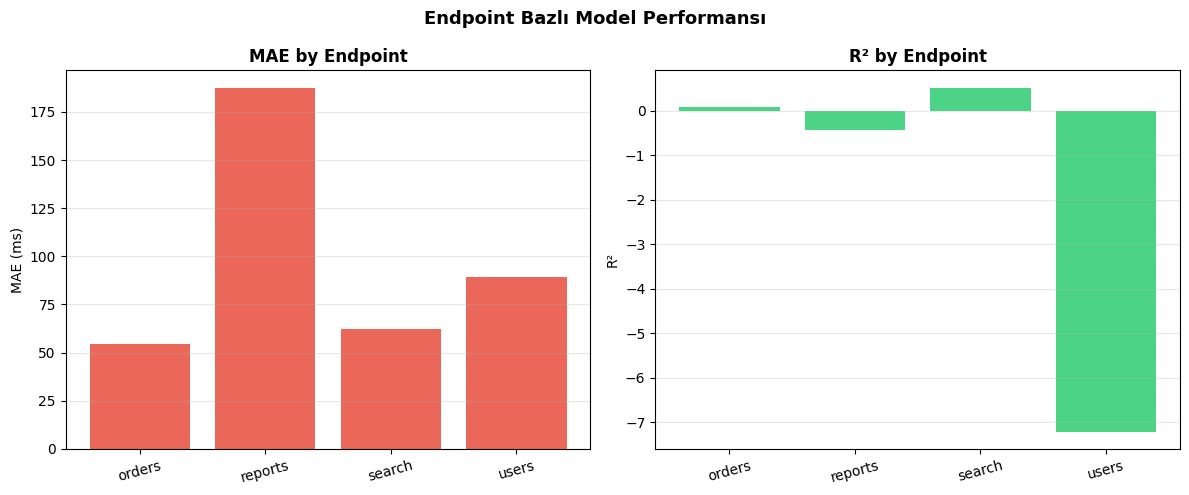

In [14]:
from sklearn.preprocessing import LabelEncoder

le = joblib.load('../models/label_encoder.pkl')

# Her test sample'ın endpoint'ini bul
test_start = split + WINDOW_SIZE
df_test = df.iloc[test_start:test_start + len(y_test)].copy()
df_test['y_true'] = y_test
df_test['y_pred'] = y_pred_rf
df_test['error']  = np.abs(df_test['y_true'] - df_test['y_pred'])

endpoint_perf = df_test.groupby('endpoint_name').agg(
    kayit_sayisi = ('y_true', 'count'),
    ort_gercek   = ('y_true', 'mean'),
    ort_tahmin   = ('y_pred', 'mean'),
    MAE          = ('error', 'mean'),
    R2           = ('y_true', lambda x: r2_score(x, df_test.loc[x.index, 'y_pred']))
).round(2)

print('Endpoint Bazlı Performans:')
print(endpoint_perf.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(endpoint_perf.index, endpoint_perf['MAE'], color='#e74c3c', alpha=0.85)
axes[0].set_title('MAE by Endpoint', fontweight='bold')
axes[0].set_ylabel('MAE (ms)')
axes[0].tick_params(axis='x', rotation=15)
axes[0].grid(alpha=0.3, axis='y')

axes[1].bar(endpoint_perf.index, endpoint_perf['R2'], color='#2ecc71', alpha=0.85)
axes[1].set_title('R² by Endpoint', fontweight='bold')
axes[1].set_ylabel('R²')
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(alpha=0.3, axis='y')

plt.suptitle('Endpoint Bazlı Model Performansı', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/endpoint_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## Endpoint Bazlı Performans Yorumu

Endpoint bazlı analiz, modelin farklı servis türlerinde belirgin performans farklılıkları gösterdiğini ortaya koymaktadır. `search` endpoint'i R² = 0.52 ile en yüksek tahmin başarısını sağlarken, `orders` endpoint'i 54.26 ms MAE ile en düşük mutlak hatayı üretmiştir.

`reports` endpoint'i yüksek ortalama gecikme (604 ms) ve yoğun spike davranışı nedeniyle tahmin edilmesi en zor endpoint olarak öne çıkmaktadır. `users` endpoint'indeki negatif R² değeri, modelin bu düşük gecikmeli ve düşük varyanslı servis türünde sistematik olarak yüksek tahmin üretmesinden kaynaklanmaktadır.

Bu bulgular, gelecek çalışmalarda endpoint bazlı ayrı modeller eğitilmesinin veya endpoint türünün model ağırlıklandırmasında daha etkin kullanılmasının performansı artırabileceğini göstermektedir.

## Kaydetme

In [15]:
os.makedirs('../data', exist_ok=True)
risk_df.to_csv('../data/risk_results.csv', index=False)

shap_summary = pd.DataFrame({
    'feature': features,
    'mean_abs_shap': np.abs(shap_grouped).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)
shap_summary.to_csv('../data/shap_summary.csv', index=False)

print('Kaydedildi.')
print(shap_summary.to_string(index=False))

Kaydedildi.
                   feature  mean_abs_shap
       response_time_lag_1      70.105912
          endpoint_encoded      47.665138
                   rps_10s      13.138907
 response_time_roll_mean_5      10.114953
  response_time_roll_std_5       8.525916
           active_requests       5.898479
              payload_size       3.516961
response_time_roll_mean_10       3.490333
       response_time_lag_2       2.176536
       response_time_lag_3       1.851516
         requests_last_60s       1.118599
